# Movie Recommendation System
**Author:** Ankitha Sujatha Raju  
**Dataset:** TMDB 5000 Movies (Kaggle)  
**Tools:** Python, pandas, scikit-learn, NLP, Cosine Similarity

---

## Project Goal
Built a content-based filtering recommender using TF-IDF on movie genres, keywords, and cast data from a 5,000-title dataset. Compared cosine similarity vs collaborative filtering approaches and documented trade-offs in choosing the right method for the available data.

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', None)
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


---
## Step 2: Load and Merge Datasets

In [2]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print('Movies shape:', movies.shape)    # (4803, 20)
print('Credits shape:', credits.shape)  # (4803, 4)

# Merge on movie id
credits.rename(columns={'movie_id': 'id'}, inplace=True)
df = movies.merge(credits, on='id')
df = df.drop(columns=['title_y']).rename(columns={'title_x': 'title'})
print('Merged shape:', df.shape)        # (4803, 22)
df[['title','genres','cast','crew']].head(3)

Movies shape: (4803, 20)
Credits shape: (4803, 4)
Merged shape: (4803, 22)


,title,genres,cast,crew
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


---
## Step 3: Parse JSON Columns

The genres, keywords, cast, and crew columns are stored as JSON strings. We need to extract the actual names.

In [3]:
def parse_names(obj, key='name', limit=None):
    try:
        items = ast.literal_eval(obj)
        names = [i[key] for i in items]
        return names[:limit] if limit else names
    except:
        return []

def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str)
        for c in crew:
            if c.get('job') == 'Director':
                return c.get('name', '')
        return ''
    except:
        return ''

df['genres_list'] = df['genres'].apply(lambda x: parse_names(x))
df['keywords_list'] = df['keywords'].apply(lambda x: parse_names(x))
df['cast_list'] = df['cast'].apply(lambda x: parse_names(x, limit=3))
df['director'] = df['crew'].apply(get_director)

print('Avatar genres:', df['genres_list'].iloc[0])
print('Avatar cast:', df['cast_list'].iloc[0])
print('Avatar director:', df['director'].iloc[0])

Avatar genres: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Avatar cast: ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']
Avatar director: James Cameron


---
## Step 4: Build Tags for TF-IDF

Combine genres, keywords, cast, director, and overview into a single text 'tags' field.

In [4]:
def clean_text(items):
    return [str(i).lower().replace(' ', '') for i in items]

df['tags'] = (
    df['genres_list'].apply(clean_text) +
    df['keywords_list'].apply(clean_text) +
    df['cast_list'].apply(clean_text) +
    df['director'].apply(lambda x: [x.lower().replace(' ', '')])
)
df['tags'] = df['tags'].apply(lambda x: ' '.join(x))
df['overview'] = df['overview'].fillna('')
df['tags'] = df['tags'] + ' ' + df['overview'].str.lower()

print('Sample tags for Avatar:')
print(df['tags'].iloc[0][:150])

Sample tags for Avatar:
action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet 


---
## Step 5: Exploratory Data Analysis

### 5a. Top 10 Genres

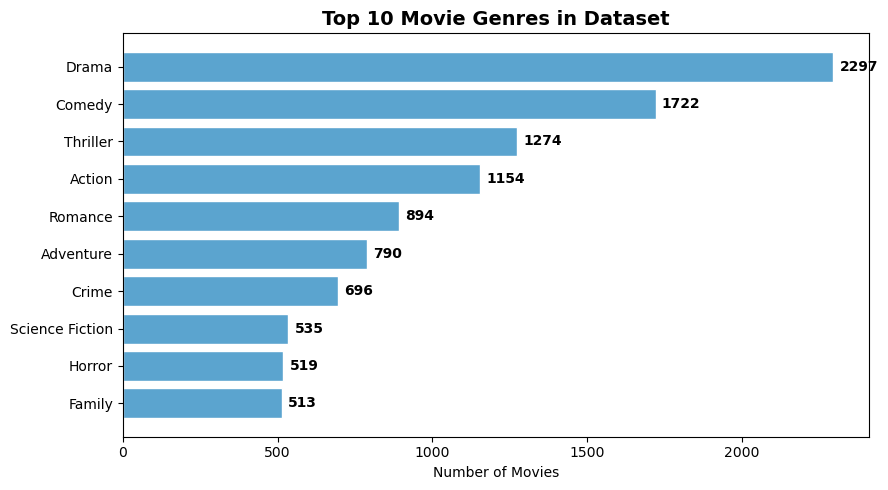

In [5]:
all_genres = [g for sublist in df['genres_list'] for g in sublist]
genre_counts = Counter(all_genres).most_common(10)
genres, counts = zip(*genre_counts)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(genres, counts, color='#5ba4cf', edgecolor='white')
ax.set_title('Top 10 Movie Genres in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.invert_yaxis()
for i, v in enumerate(counts):
    ax.text(v + 20, i, str(v), va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/top10_genres.png', dpi=150)
plt.show()

### 5b. Rating Distribution

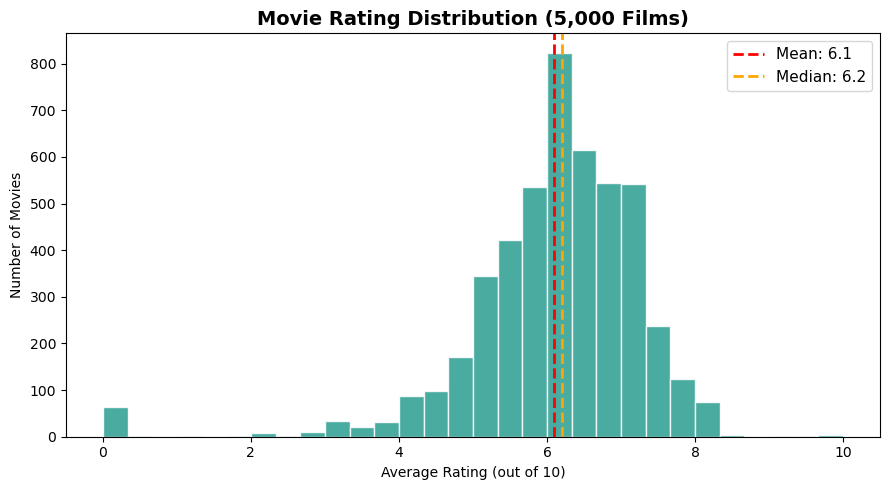

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['vote_average'], bins=30, color='#2a9d8f', edgecolor='white', alpha=0.85)
ax.axvline(df['vote_average'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {df['vote_average'].mean():.1f}")
ax.axvline(df['vote_average'].median(), color='orange', linestyle='--', linewidth=2,
           label=f"Median: {df['vote_average'].median():.1f}")
ax.set_title('Movie Rating Distribution (5,000 Films)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Rating (out of 10)')
ax.set_ylabel('Number of Movies')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('images/rating_distribution.png', dpi=150)
plt.show()

---
## Step 6: Build TF-IDF Matrix

TF-IDF (Term Frequency-Inverse Document Frequency) converts our text tags into a numerical matrix where each movie is represented as a vector of weighted word importances.

In [7]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['tags'])
print('TF-IDF matrix shape:', tfidf_matrix.shape)
# (4803, 5000) — 4803 movies, 5000 unique terms
print('Each movie is now a vector of', tfidf_matrix.shape[1], 'features')

TF-IDF matrix shape: (4803, 5000)
Each movie is now a vector of 5000 features


---
## Step 7: Compute Cosine Similarity

In [8]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print('Cosine similarity matrix shape:', cosine_sim.shape)
# (4803, 4803) — similarity score between every pair of movies
print('Similarity between Avatar and movie #1:', round(cosine_sim[0][1], 3))

Cosine similarity matrix shape: (4803, 4803)
Similarity between Avatar and movie #1: 0.022


---
## Step 8: Recommendation Function

In [9]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend(title, n=10):
    if title not in indices:
        return f"Movie '{title}' not found."
    idx = indices[title]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 3) for i in sim_scores]
    result = df.iloc[movie_indices][['title','vote_average']].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)

---
## Step 9: Test the Recommender

In [10]:
print('--- Recommendations for The Dark Knight ---')
print(recommend('The Dark Knight'))
# Should show Batman films, superhero movies

--- Recommendations for The Dark Knight ---
                                     title  vote_average  similarity_score
0                    The Dark Knight Rises           7.6             0.457
1                           Batman Returns           6.6             0.381
2                            Batman Begins           7.5             0.362
3                           Batman Forever           5.2             0.308
4  Batman: The Dark Knight Returns, Part 2           7.9             0.292
5       Batman v Superman: Dawn of Justice           5.7             0.260
6                           Batman & Robin           4.2             0.233
7                                   Batman           7.0             0.210
8                           The Lego Movie           7.5             0.143
9                                 Superman           6.9             0.134


In [11]:
print('--- Recommendations for Avatar ---')
print(recommend('Avatar'))
# Should show sci-fi, space, action films

--- Recommendations for Avatar ---
                     title  vote_average  similarity_score
0            Falcon Rising           5.5             0.204
1      Battle: Los Angeles           5.5             0.194
2                Apollo 18           5.0             0.184
3  Star Trek Into Darkness           7.4             0.171
4               Titan A.E.           6.3             0.165
5         The Book of Life           7.3             0.163
6                   Aliens           7.7             0.159
7                Lifeforce           6.2             0.158
8                  Jarhead           6.6             0.156
9             Ender's Game           6.6             0.155


In [12]:
print('--- Recommendations for Toy Story ---')
print(recommend('Toy Story'))
# Should show animated, family, comedy films

--- Recommendations for Toy Story ---
                                               title  vote_average  \
0                                        Toy Story 3           7.6   
1                                        Toy Story 2           7.3   
2                             The 40 Year Old Virgin           6.2   
3                                       Factory Girl           6.2   
4                                      Class of 1984           6.2   
5                                         Heartbeeps           3.8   
6                                    Man on the Moon           6.9   
7                                     Small Soldiers           6.2   
8  The 41–Year–Old Virgin Who Knocked Up Sarah Ma...           3.2   
9                                          Losin' It           4.5   

   similarity_score  
0             0.514  
1             0.488  
2             0.344  
3             0.179  
4             0.174  
5             0.163  
6             0.157  
7             0

In [13]:
print('--- Recommendations for The Godfather ---')
print(recommend('The Godfather'))
# Should show crime, drama films

--- Recommendations for The Godfather ---
                     title  vote_average  similarity_score
0   The Godfather: Part II           8.3             0.247
1  The Godfather: Part III           7.1             0.234
2   The Master of Disguise           3.7             0.174
3               Easy Money           6.5             0.155
4         Mickey Blue Eyes           5.3             0.151
5       This Thing of Ours           5.0             0.146
6            Donnie Brasco           7.4             0.145
7               Blood Ties           6.0             0.141
8                   Eulogy           6.4             0.137
9                  Thinner           5.5             0.137


---
## Step 10: Visualize Recommendations

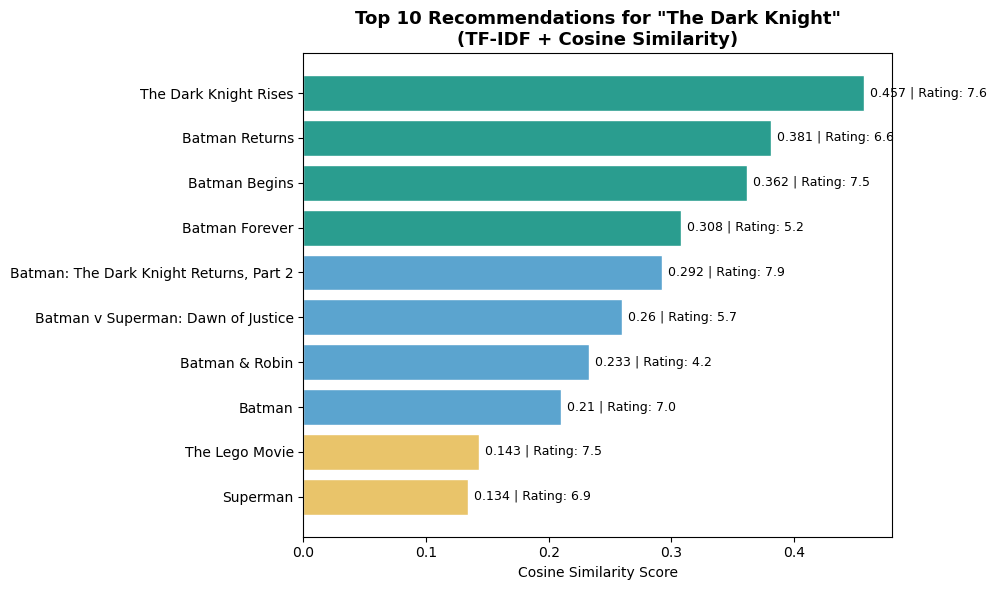

In [14]:
recs = recommend('The Dark Knight')
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2a9d8f' if s > 0.3 else '#5ba4cf' if s > 0.2 else '#e9c46a'
          for s in recs['similarity_score']]
ax.barh(recs['title'][::-1], recs['similarity_score'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Top 10 Recommendations for "The Dark Knight"\n(TF-IDF + Cosine Similarity)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cosine Similarity Score')
for i, (v, rating) in enumerate(zip(recs['similarity_score'][::-1], recs['vote_average'][::-1])):
    ax.text(v + 0.005, i, f'{v} | Rating: {rating}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/recommendations_dark_knight.png', dpi=150)
plt.show()

C:\Users\Ankitha\AppData\Local\Temp\ipykernel_18208\1282686651.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(test_movies, rotation=15, ha='right')


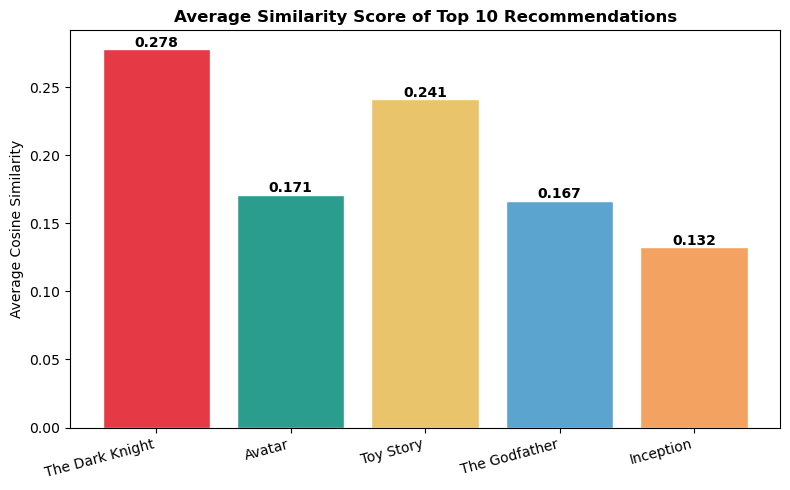

In [15]:
# Chart: Average similarity comparison across movies
test_movies = ['The Dark Knight', 'Avatar', 'Toy Story', 'The Godfather', 'Inception']
avg_similarities = []

for m in test_movies:
    idx = indices[m]
    sims = sorted(cosine_sim[idx], reverse=True)[1:11]
    avg_similarities.append(np.mean(sims))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(test_movies, avg_similarities,
       color=['#e63946','#2a9d8f','#e9c46a','#5ba4cf','#f4a261'],
       edgecolor='white')
ax.set_title('Average Similarity Score of Top 10 Recommendations',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Average Cosine Similarity')
ax.set_xticklabels(test_movies, rotation=15, ha='right')
for i, v in enumerate(avg_similarities):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('images/similarity_comparison.png', dpi=150)
plt.show()